# Task 1.1
### Data Cleaning

This section loads the NSW region summary dataset and prepares a cleaned version for analysis. The main issue in this file is that many indicators are only available in selected years, so missing values should not be filled with zero. Instead, the workflow keeps the original values, standardises the column names, extracts the unit from each indicator description, counts how many valid years each indicator has, and reshapes the dataset into a long format for later statistics and visualisation.

In [8]:
import pandas as pd
from pathlib import Path
from IPython.display import display

current_dir = Path.cwd()
data_path = current_dir / "data" / "Region summary_ New South Wales STE 1.csv"

df = pd.read_csv(data_path)
display(df.head())


,Measure Code,Parent Description,Description,2011,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,ERP_P_20,Estimated resident population - year ended 30 ...,Estimated resident population (no.),NaN,NaN,NaN,NaN,NaN,8046748.0,8110610.0,8097062.0,8166704.0,8341199.0,8479314.0,NaN
1,ERP_21,Estimated resident population - year ended 30 ...,Population density (persons/km2),NaN,NaN,NaN,NaN,NaN,10.0,10.1,10.1,10.2,10.4,10.6,NaN
2,ERP_M_20,Estimated resident population - year ended 30 ...,Estimated resident population - males (no.),NaN,NaN,NaN,NaN,NaN,3999452.0,4030710.0,4025393.0,4059763.0,4149032.0,4217861.0,NaN
3,ERP_F_20,Estimated resident population - year ended 30 ...,Estimated resident population - females (no.),NaN,NaN,NaN,NaN,NaN,4047296.0,4079900.0,4071669.0,4106941.0,4192167.0,4261453.0,NaN
4,ERP_19,Estimated resident population - year ended 30 ...,Median age - males (years),NaN,NaN,NaN,NaN,NaN,36.8,37.2,37.7,37.7,37.5,37.5,NaN


## Cleaning logic

The raw table is a wide table, which means each row is one indicator and each year is stored in a separate column. To make the data easier to analyse, the cleaning step below does three things. First, it standardises the text column names and year column names. Second, it separates the measurement unit from the description column and records how many non-null years each indicator has. Third, it reshapes the table into a long format so that each row represents one indicator-year value.

In [9]:
task1_df = df.rename(
    columns={
        "Measure Code": "measure_code",
        "Parent Description": "parent_description",
        "Description": "description",
    }
).copy()

task1_df.columns = [f"y_{col}" if str(col).isdigit() else col for col in task1_df.columns]
year_cols = [col for col in task1_df.columns if col.startswith("y_")]

task1_df["unit"] = task1_df["description"].str.extract(r"\(([^()]*)\)\s*$")
task1_df["description_clean"] = task1_df["description"].str.replace(r"\s*\([^()]*\)\s*$", "", regex=True)
task1_df["non_null_years"] = task1_df[year_cols].notna().sum(axis=1)
task1_df = task1_df[task1_df["non_null_years"] > 0].copy()

task1_long_df = task1_df.melt(
    id_vars=["measure_code", "parent_description", "description_clean", "unit"],
    value_vars=year_cols,
    var_name="year",
    value_name="value",
)

task1_long_df = task1_long_df.dropna(subset=["value"]).copy()
task1_long_df["year"] = task1_long_df["year"].str.replace("y_", "").astype(int)
task1_analysis_df = (
    task1_long_df[task1_long_df["year"] != 2025]
    .drop_duplicates(subset=["measure_code", "description_clean", "year"])
    .copy()
)

cleaning_summary_df = pd.DataFrame(
    {
        "item": [
            "original_rows",
            "rows_after_drop_all_null_years",
            "long_table_rows",
            "analysis_rows_without_2025",
            "rows_with_only_one_non_null_year",
            "non_null_values_in_2025",
        ],
        "value": [
            len(df),
            len(task1_df),
            len(task1_long_df),
            len(task1_analysis_df),
            int((task1_df["non_null_years"] == 1).sum()),
            int(task1_long_df[task1_long_df["year"] == 2025].shape[0]),
        ],
    }
)

display(cleaning_summary_df)
display(task1_df.head())
display(task1_analysis_df.head())


,item,value
0,original_rows,800
1,rows_after_drop_all_null_years,800
2,long_table_rows,2874
3,analysis_rows_without_2025,2871
4,rows_with_only_one_non_null_year,105
5,non_null_values_in_2025,3


,measure_code,parent_description,description,y_2011,y_2015,y_2016,y_2017,y_2018,y_2019,y_2020,y_2021,y_2022,y_2023,y_2024,y_2025,unit,description_clean,non_null_years
0,ERP_P_20,Estimated resident population - year ended 30 ...,Estimated resident population (no.),NaN,NaN,NaN,NaN,NaN,8046748.0,8110610.0,8097062.0,8166704.0,8341199.0,8479314.0,NaN,no.,Estimated resident population,6
1,ERP_21,Estimated resident population - year ended 30 ...,Population density (persons/km2),NaN,NaN,NaN,NaN,NaN,10.0,10.1,10.1,10.2,10.4,10.6,NaN,persons/km2,Population density,6
2,ERP_M_20,Estimated resident population - year ended 30 ...,Estimated resident population - males (no.),NaN,NaN,NaN,NaN,NaN,3999452.0,4030710.0,4025393.0,4059763.0,4149032.0,4217861.0,NaN,no.,Estimated resident population - males,6
3,ERP_F_20,Estimated resident population - year ended 30 ...,Estimated resident population - females (no.),NaN,NaN,NaN,NaN,NaN,4047296.0,4079900.0,4071669.0,4106941.0,4192167.0,4261453.0,NaN,no.,Estimated resident population - females,6
4,ERP_19,Estimated resident population - year ended 30 ...,Median age - males (years),NaN,NaN,NaN,NaN,NaN,36.8,37.2,37.7,37.7,37.5,37.5,NaN,years,Median age - males,6


,measure_code,parent_description,description_clean,unit,year,value
127,CENSUS_34,Aboriginal and Torres Strait Islander Peoples ...,Aboriginal and Torres Strait Islander Peoples,no.,2011,172620.0
128,CENSUS_2,Aboriginal and Torres Strait Islander Peoples ...,Aboriginal and Torres Strait Islander Peoples,%,2011,2.5
140,CENSUS_15,Religious affiliation - Census,Buddhism,%,2011,2.9
141,CENSUS_16,Religious affiliation - Census,Christianity,%,2011,64.5
142,CENSUS_17,Religious affiliation - Census,Hinduism,%,2011,1.7


# Derived Statistics 1.2


## 1.2.4 Housing-related derived statistics（by Qianxue Yu)
This section creates five derived housing statistics from the cleaned Task 1 data.


In [10]:
vehicle_groups = {
    "VEHIC_2": "no_motor_vehicle",
    "VEHIC_3": "one_motor_vehicle",
    "VEHIC_4": "two_motor_vehicles",
    "VEHIC_5": "three_motor_vehicles",
    "VEHIC_6": "four_or_more_motor_vehicles",
}

vehicle_df = task1_analysis_df[
    task1_analysis_df["measure_code"].isin(vehicle_groups)
][["measure_code", "year", "value"]].copy()
vehicle_df["vehicle_group"] = vehicle_df["measure_code"].map(vehicle_groups)

vehicle_wide = (
    vehicle_df
    .pivot(index="year", columns="vehicle_group", values="value")
    .reset_index()
    .sort_values("year")
)
vehicle_wide.columns.name = None
vehicle_wide["total_private_households"] = vehicle_wide[list(vehicle_groups.values())].sum(axis=1)

display(vehicle_wide)


,year,four_or_more_motor_vehicles,no_motor_vehicle,one_motor_vehicle,three_motor_vehicles,two_motor_vehicles,total_private_households
0,2011,115060.0,258153.0,933951.0,245022.0,840660.0,2392846.0
1,2016,152006.0,239627.0,946160.0,283045.0,887849.0,2508687.0
2,2021,187380.0,262031.0,1096761.0,321310.0,989258.0,2856740.0


### Statistic 1: Total private households growth
Compares total private households across Census years.

Raw data: `VEHIC_2`-`VEHIC_6`

Formula: `(current total households - previous total households) / previous total households × 100`

Interpretation: A positive value means the number of private households increased.


In [11]:
household_growth_df = vehicle_wide[["year", "total_private_households"]].copy()
household_growth_df["household_change"] = household_growth_df["total_private_households"].diff()
household_growth_df["household_growth_rate"] = (
    household_growth_df["total_private_households"].pct_change() * 100
)

display(household_growth_df)


,year,total_private_households,household_change,household_growth_rate
0,2011,2392846.0,NaN,NaN
1,2016,2508687.0,115841.0,4.841139
2,2021,2856740.0,348053.0,13.873911


### Statistic 2: Households with no motor vehicle
Compares households with no motor vehicle with total private households.

Raw data: `VEHIC_2`, `VEHIC_2`-`VEHIC_6`

Formula: `no motor vehicle households / total private households × 100`

Interpretation: A higher value means a larger share of households do not have a motor vehicle.


In [12]:
no_vehicle_share_df = vehicle_wide[[
    "year", "no_motor_vehicle", "total_private_households"
]].copy()
no_vehicle_share_df["no_vehicle_share"] = (
    no_vehicle_share_df["no_motor_vehicle"]
    / no_vehicle_share_df["total_private_households"]
    * 100
)

display(no_vehicle_share_df)


,year,no_motor_vehicle,total_private_households,no_vehicle_share
0,2011,258153.0,2392846.0,10.788534
1,2016,239627.0,2508687.0,9.551889
2,2021,262031.0,2856740.0,9.172378


### Statistic 3: Average motor vehicles per household
Combines household counts by vehicle category to estimate average vehicle ownership.

Raw data: `VEHIC_2`-`VEHIC_6`

Formula: `weighted motor vehicle count / total private households`

Interpretation: A higher value means households own more motor vehicles on average.


In [13]:
vehicle_weights = {
    "no_motor_vehicle": 0,
    "one_motor_vehicle": 1,
    "two_motor_vehicles": 2,
    "three_motor_vehicles": 3,
    "four_or_more_motor_vehicles": 4,
}

average_vehicle_df = vehicle_wide[["year", "total_private_households"]].copy()
average_vehicle_df["weighted_vehicle_count"] = sum(
    vehicle_wide[col] * weight for col, weight in vehicle_weights.items()
)
average_vehicle_df["average_vehicles_per_household"] = (
    average_vehicle_df["weighted_vehicle_count"]
    / average_vehicle_df["total_private_households"]
)

display(average_vehicle_df)


,year,total_private_households,weighted_vehicle_count,average_vehicles_per_household
0,2011,2392846.0,3810577.0,1.592487
1,2016,2508687.0,4179017.0,1.665818
2,2021,2856740.0,4788727.0,1.676291


### Statistic 4: Urban intensive land use proportion
Compares urban intensive land use with total land use.

Raw data: `LANDUSE_13`, `LANDUSE_19`

Formula: `urban intensive land use / total land use × 100`

Interpretation: A higher value means a larger share of land is used for intensive urban purposes.


In [14]:
land_use_wide = (
    task1_analysis_df[task1_analysis_df["measure_code"].isin(["LANDUSE_13", "LANDUSE_19"])]
    .pivot(index="year", columns="measure_code", values="value")
    .rename(columns={"LANDUSE_13": "urban_intensive_use", "LANDUSE_19": "total_land_use"})
    .reset_index()
)
land_use_wide.columns.name = None

urban_land_use_df = land_use_wide[["year", "urban_intensive_use", "total_land_use"]].copy()
urban_land_use_df["urban_intensive_land_use_share"] = (
    urban_land_use_df["urban_intensive_use"]
    / urban_land_use_df["total_land_use"]
    * 100
)

display(urban_land_use_df)


,year,urban_intensive_use,total_land_use,urban_intensive_land_use_share
0,2016,684281.0,80129856.0,0.853965


### Statistic 5: Population density growth
Compares current-year population density with previous-year population density.

Raw data: `ERP_21`

Formula: `(current density - previous density) / previous density × 100`

Interpretation: A positive value means population density increased.


In [15]:
housing_density_growth_df = (
    task1_analysis_df[task1_analysis_df["measure_code"] == "ERP_21"]
    [["year", "value"]]
    .rename(columns={"value": "population_density"})
    .sort_values("year")
    .reset_index(drop=True)
)
housing_density_growth_df["density_change"] = housing_density_growth_df["population_density"].diff()
housing_density_growth_df["density_growth_rate"] = (
    housing_density_growth_df["population_density"].pct_change() * 100
)

display(housing_density_growth_df)


,year,population_density,density_change,density_growth_rate
0,2019,10.0,NaN,NaN
1,2020,10.1,0.1,1.000000
2,2021,10.1,0.0,0.000000
3,2022,10.2,0.1,0.990099
4,2023,10.4,0.2,1.960784
5,2024,10.6,0.2,1.923077


# Task 2

This section builds the geographic dataset for four selected areas. Each area is linked to one SA4 zone. For each selected SA4, the workflow uses the local ABS 2021 SA4 and SA2 shapefiles to identify the SA2 regions contained inside that SA4. It then uses the NSW POI API to collect POIs around each SA2 bounding box and filters the returned points with the SA2 polygon before saving the combined results to a local SQLite database.

## Selected SA4 codes

The group uses four SA4 codes: `120`, `117`, `118`, and `125`. The setup cell below matches each code to its official SA4 name and defines a small helper function so the same logic can be reused for each selected area.

In [16]:
import importlib
import task2_sa2

importlib.reload(task2_sa2)

available_sa4s = task2_sa2.list_nsw_sa4s()
area_zone_df = pd.DataFrame(
    {
        "area_name": ["area_1", "area_2", "area_3", "area_4"],
        "sa4_code": ["120", "117", "118", "125"],
    }
)

area_zone_df = area_zone_df.merge(
    available_sa4s.rename(columns={"SA4_CODE": "sa4_code", "SA4_NAME": "sa4_name"}),
    on="sa4_code",
    how="left",
)

def run_area_zone(area_name, sa4_code):
    sa2_bbox_df = task2_sa2.get_sa2_bbox_df_by_code(sa4_code)
    poi_df = task2_sa2.get_sa4_poi_df_by_code(sa4_code)
    sa2_bbox_df["area_name"] = area_name
    poi_df["area_name"] = area_name
    poi_count_df = poi_df.groupby("sa2_name").size().reset_index(name="poi_count")
    return sa2_bbox_df, poi_df, poi_count_df.sort_values("poi_count", ascending=False)

display(area_zone_df)


,area_name,sa4_code,sa4_name
0,area_1,120,Sydney - Inner West
1,area_2,117,Sydney - City and Inner South
2,area_3,118,Sydney - Eastern Suburbs
3,area_4,125,Sydney - Parramatta


## Area 3

Area 3 is linked to `SA4_CODE = 118`, which corresponds to `Sydney - Eastern Suburbs`. Keeping the outputs separate makes it easier to show which SA2 and POI records belong to each selected area.

In [17]:
area_3_sa2_bbox_df, area_3_poi_df, area_3_poi_count_df = run_area_zone("area_3", "118")
display(area_3_sa2_bbox_df[["area_name", "sa4_code", "sa4_name", "sa2_main", "sa2_name"]])
display(area_3_poi_df.head())
display(area_3_poi_count_df)


,area_name,sa4_code,sa4_name,sa2_main,sa2_name
0,area_3,118,Sydney - Eastern Suburbs,118011339,Bondi - Tamarama - Bronte
1,area_3,118,Sydney - Eastern Suburbs,118011340,Bondi Beach - North Bondi
2,area_3,118,Sydney - Eastern Suburbs,118011341,Bondi Junction - Waverly
3,area_3,118,Sydney - Eastern Suburbs,118011342,Centennial Park
4,area_3,118,Sydney - Eastern Suburbs,118011344,Dover Heights
5,area_3,118,Sydney - Eastern Suburbs,118011345,Paddington - Moore Park
6,area_3,118,Sydney - Eastern Suburbs,118011346,Rose Bay - Vaucluse - Watsons Bay
7,area_3,118,Sydney - Eastern Suburbs,118011347,Woollahra
8,area_3,118,Sydney - Eastern Suburbs,118011649,Bellevue Hill
9,area_3,118,Sydney - Eastern Suburbs,118011650,Double Bay - Darling Point


,objectid,poiname,poitype,poigroup,longitude,latitude,sa4_code,sa4_name,sa2_main,sa2_name,area_name
0,2296,MARKS PARK,Park,3,151.275150,-33.898499,118,Sydney - Eastern Suburbs,118011339,Bondi - Tamarama - Bronte,area_3
1,2297,WAVERLEY CEMETERY,Cemetery,1,151.266912,-33.908876,118,Sydney - Eastern Suburbs,118011339,Bondi - Tamarama - Bronte,area_3
2,27165,BET YOSEF (THE CARO SYNAGOGUE),Place Of Worship,1,151.261588,-33.888442,118,Sydney - Eastern Suburbs,118011339,Bondi - Tamarama - Bronte,area_3
3,27172,MARLBOROUGH RESERVE,Park,3,151.259434,-33.899592,118,Sydney - Eastern Suburbs,118011339,Bondi - Tamarama - Bronte,area_3
4,27173,BONDI PRESBYTERIAN CHURCH,Place Of Worship,1,151.267429,-33.893458,118,Sydney - Eastern Suburbs,118011339,Bondi - Tamarama - Bronte,area_3


,sa2_name,poi_count
18,Rose Bay - Vaucluse - Watsons Bay,141
10,Malabar - La Perouse,119
15,Paddington - Moore Park,85
3,Bondi Junction - Waverly,77
5,Coogee - Clovelly,66
2,Bondi Beach - North Bondi,62
17,Randwick - South,51
14,Matraville - Chifley,50
0,Bellevue Hill,46
16,Randwick - North,43


# Task 3: SQL score calculation

This section calculates the well-resourced score only for Area 3.

Area 3 is linked to `SA4_CODE = 118`, which corresponds to `Sydney - Eastern Suburbs`.

For each SA2 region in Area 3, the POI count is calculated first. Then the POI count is standardised using a z-score. Finally, the sigmoid function is applied to convert the z-score into a score between 0 and 1.

The scoring formula is:

$$Score = S(z_{POI}) = \frac{1}{1 + e^{-z_{POI}}}$$

Where:

- `poi_count` = number of POIs in each SA2

- `z_poi` = standardised POI count

- `score` = final well-resourced score between 0 and 1

A higher score means the SA2 region has more POIs compared with other SA2 regions in Area 3.

In [ ]:
# Task 3: Read and display Area 3 well-resourced scores

import pandas as pd
import sqlite3
from pathlib import Path

# Step 1: Set the database path
db_path = Path("data") / "task2_poi.db"

# Step 2: Connect to the SQLite database
conn = sqlite3.connect(db_path)

# Step 3: Read only Area 3 scores from the sa2_scores table
# Area 3 corresponds to SA4_CODE = 118
area_3_score_df = pd.read_sql_query(
    """
    SELECT
        area_name,
        sa4_code,
        sa4_name,
        sa2_main,
        sa2_name,
        area_sqkm,
        poi_count,
        z_poi,
        score
    FROM sa2_scores
    WHERE area_name = 'area_3'
       OR sa4_code = '118'
    ORDER BY score DESC
    """,
    conn
)

# Step 4: Close the database connection
conn.close()

# Step 5: Create a summary table for Area 3
area_3_score_summary = pd.DataFrame({
    "area_name": ["area_3"],
    "sa4_code": ["118"],
    "sa4_name": ["Sydney - Inner South West"],
    "number_of_sa2": [area_3_score_df["sa2_main"].nunique()],
    "total_poi": [area_3_score_df["poi_count"].sum()],
    "mean_poi_count": [area_3_score_df["poi_count"].mean()],
    "min_score": [area_3_score_df["score"].min()],
    "mean_score": [area_3_score_df["score"].mean()],
    "max_score": [area_3_score_df["score"].max()]
})

# Step 6: Display the Area 3 results
display(area_3_score_summary)
display(area_3_score_df)

,area_name,sa4_code,sa4_name,number_of_sa2,total_poi,mean_poi_count,min_score,mean_score,max_score
0,area_3,118,Sydney - Inner South West,21,1113,53.0,0.235986,0.4825,0.946433


,area_name,sa4_code,sa4_name,sa2_main,sa2_name,area_sqkm,poi_count,z_poi,score
0,area_3,118,Sydney - Eastern Suburbs,118011346,Rose Bay - Vaucluse - Watsons Bay,5.1368,141,2.871771,0.946433
1,area_3,118,Sydney - Eastern Suburbs,118021652,Malabar - La Perouse,8.4115,119,2.153829,0.896026
2,area_3,118,Sydney - Eastern Suburbs,118011345,Paddington - Moore Park,3.7250,85,1.044281,0.739675
3,area_3,118,Sydney - Eastern Suburbs,118011341,Bondi Junction - Waverly,2.5235,77,0.783210,0.686372
4,area_3,118,Sydney - Eastern Suburbs,118021651,Coogee - Clovelly,2.7034,66,0.424239,0.604497
5,area_3,118,Sydney - Eastern Suburbs,118011340,Bondi Beach - North Bondi,2.4604,62,0.293704,0.572903
6,area_3,118,Sydney - Eastern Suburbs,118021570,Randwick - South,3.3725,51,-0.065268,0.483689
7,area_3,118,Sydney - Eastern Suburbs,118021653,Matraville - Chifley,3.4138,50,-0.097901,0.475544
8,area_3,118,Sydney - Eastern Suburbs,118011649,Bellevue Hill,3.1556,46,-0.228436,0.443138
9,area_3,118,Sydney - Eastern Suburbs,118021569,Randwick - North,1.9356,43,-0.326338,0.419132


## Spatial indexing and PostGIS-compatible SQL

The active submitted database contains normal lookup indexes plus an RTree spatial index over POI longitude/latitude. The PostGIS-equivalent workflow is provided in `sql/postgis_workflow.sql`; it uses `ST_Covers`, GiST geometry indexes, SQL aggregation, z-score standardisation, sigmoid scoring, and SQL `corr()` for the score-income relationship.

# Task 4: Scores visualisation

This section prepares the three visualisations used in the report:

- distribution of SA2 well-resourced scores
- score variation across SA4 regions
- map-overlay visualisation of SA2 scores

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from shapely.geometry import Polygon, MultiPolygon

import task2_sa2

scores_df = task2_sa2.read_sql(
    """
    SELECT *
    FROM sa2_scores
    ORDER BY sa4_code, score DESC
    """,
    task2_sa2.DEFAULT_DB_PATH
)


/Users/yumi/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


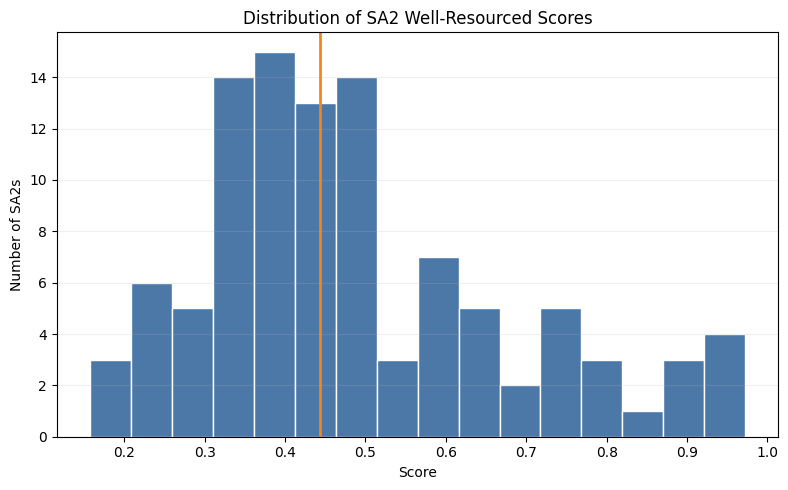

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    scores_df["score"],
    bins=16,
    color="#4C78A8",
    edgecolor="white"
)


ax.axvline(
    scores_df["score"].median(),
    color="#F58518",
    linewidth=2
)

ax.set_title("Distribution of SA2 Well-Resourced Scores")
ax.set_xlabel("Score")
ax.set_ylabel("Number of SA2s")
ax.grid(axis="y", alpha=0.2)

fig.tight_layout()
plt.show()

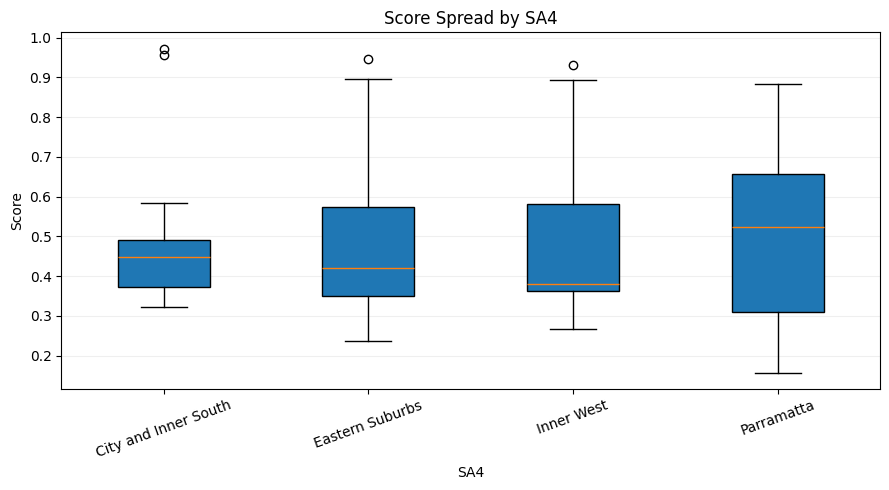

In [ ]:
scores_sorted = scores_df.sort_values("sa4_code")

grouped = [
    group["score"].to_numpy()
    for _, group in scores_sorted.groupby("sa4_name")
]

labels = [
    name.replace("Sydney - ", "")
    for name, _ in scores_sorted.groupby("sa4_name")
]

fig, ax = plt.subplots(figsize=(9, 5))

ax.boxplot(
    grouped,
    tick_labels=labels,
    patch_artist=True
)

ax.set_title("Score Spread by SA4")
ax.set_xlabel("SA4")
ax.set_ylabel("Score")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.2)

fig.tight_layout()
plt.show()

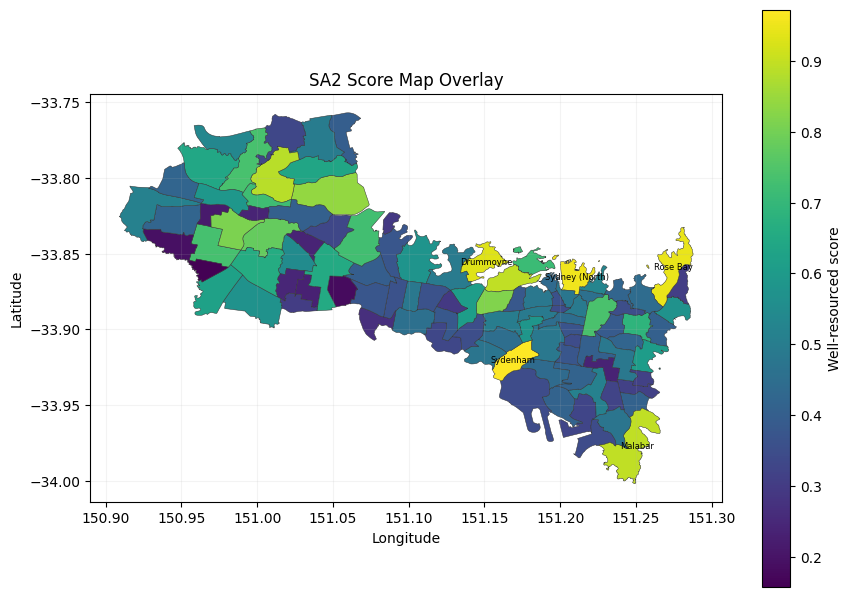

In [ ]:
score_lookup = scores_df.set_index("sa2_main")["score"].to_dict()
name_lookup = scores_df.set_index("sa2_main")["sa2_name"].to_dict()

features = [
    feature
    for feature in task2_sa2._load_sa2_features()
    if feature["SA2_CODE21"] in score_lookup
]

norm = Normalize(
    vmin=scores_df["score"].min(),
    vmax=scores_df["score"].max()
)

cmap = plt.get_cmap("viridis")

fig, ax = plt.subplots(figsize=(9, 8))

for feature in features:
    sa2_code = feature["SA2_CODE21"]
    score = score_lookup[sa2_code]
    color = cmap(norm(score))
    geometry = feature["geometry"]

    if isinstance(geometry, Polygon):
        polygons = [geometry]
    elif isinstance(geometry, MultiPolygon):
        polygons = list(geometry.geoms)
    else:
        polygons = []

    for polygon in polygons:
        x, y = polygon.exterior.xy
        ax.fill(
            x,
            y,
            facecolor=color,
            edgecolor="#333333",
            linewidth=0.35
        )


top_labels = scores_df.nlargest(5, "score")["sa2_main"].tolist()

for feature in features:
    sa2_code = feature["SA2_CODE21"]

    if sa2_code not in top_labels:
        continue

    point = feature["geometry"].representative_point()

    ax.text(
        point.x,
        point.y,
        name_lookup[sa2_code].split(" - ")[0],
        fontsize=6,
        ha="center",
        va="center",
        color="black"
    )

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, shrink=0.75)
cbar.set_label("Well-resourced score")

ax.set_title("SA2 Score Map Overlay")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.15)

fig.tight_layout()
plt.show()